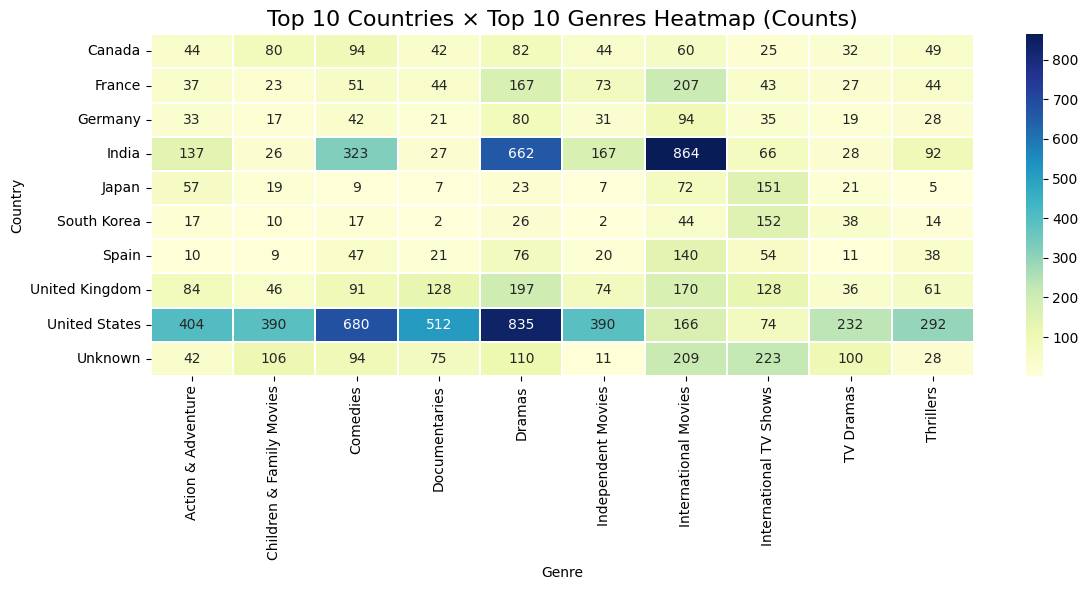

<Figure size 1200x600 with 0 Axes>

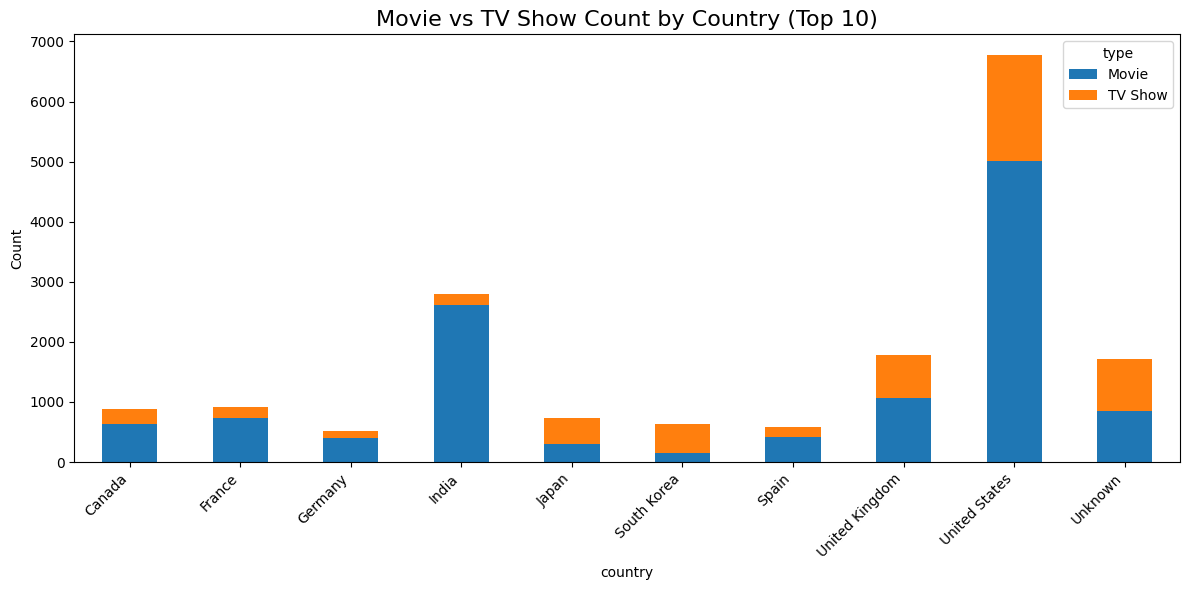

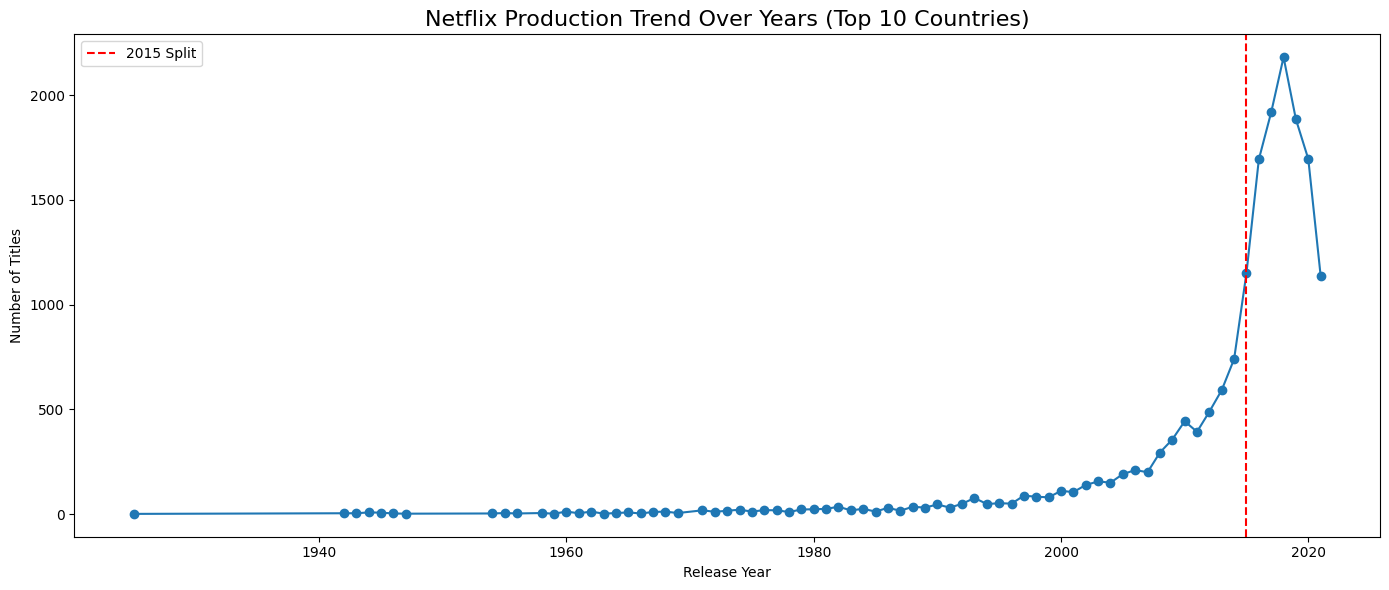

In [0]:

#NETFLIX CONTENT ANALYSIS — FINAL FULL CODE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# LOAD & CLEAN DATA
df = pd.read_csv("/Workspace/Users/hemavarshinis.23aid@kongu.edu/netflix_feature_engineered2.csv")

df['country'] = df['country'].fillna("Unknown")
df['listed_in'] = df['listed_in'].fillna("Unknown")
df['type'] = df['type'].fillna("Unknown")
df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')

df['country'] = df['country'].str.split(',')
df['listed_in'] = df['listed_in'].str.split(',')

df = df.explode('country')
df = df.explode('listed_in')

df['country'] = df['country'].str.strip()
df['listed_in'] = df['listed_in'].str.strip()


# SELECT TOP 10 COUNTRIES AND TOP 10 GENRES
top10_countries = df['country'].value_counts().head(10).index.tolist()
top10_genres = df['listed_in'].value_counts().head(10).index.tolist()

df_top = df[(df['country'].isin(top10_countries)) & (df['listed_in'].isin(top10_genres))]


# 1) HEATMAP — TOP 10 COUNTRIES × TOP 10 GENRES (ANNOTATED)
pivot_heatmap = df_top.pivot_table(
    index='country',
    columns='listed_in',
    values='show_id',
    aggfunc='count',
    fill_value=0
)

plt.figure(figsize=(12,6))
sns.heatmap(
    pivot_heatmap,
    cmap='YlGnBu',
    linewidths=0.3,
    annot=True,     # <-- Show numbers
    fmt='d'         # <-- Integer formatting
)
plt.title("Top 10 Countries × Top 10 Genres Heatmap (Counts)", fontsize=16)
plt.xlabel("Genre")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


# 2) MOVIES vs TV SHOWS — COUNT (Top 10 Countries)
df_top10_country = df[df['country'].isin(top10_countries)]

country_type_counts = df_top10_country.pivot_table(
    index='country',
    columns='type',
    values='show_id',
    aggfunc='count',
    fill_value=0
)

plt.figure(figsize=(12, 6))
country_type_counts[['Movie', 'TV Show']].plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6)
)
plt.title("Movie vs TV Show Count by Country (Top 10)", fontsize=16)
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 3) NETFLIX PRODUCTION TREND — TOP 10 COUNTRIES ONLY
df_top10_yearly = df_top10_country.groupby('release_year').size()

plt.figure(figsize=(14, 6))
plt.plot(df_top10_yearly.index, df_top10_yearly.values, marker='o')
plt.axvline(2015, linestyle='--', color='red', label="2015 Split")
plt.title("Netflix Production Trend Over Years (Top 10 Countries)", fontsize=16)
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.legend()
plt.tight_layout()
plt.show()


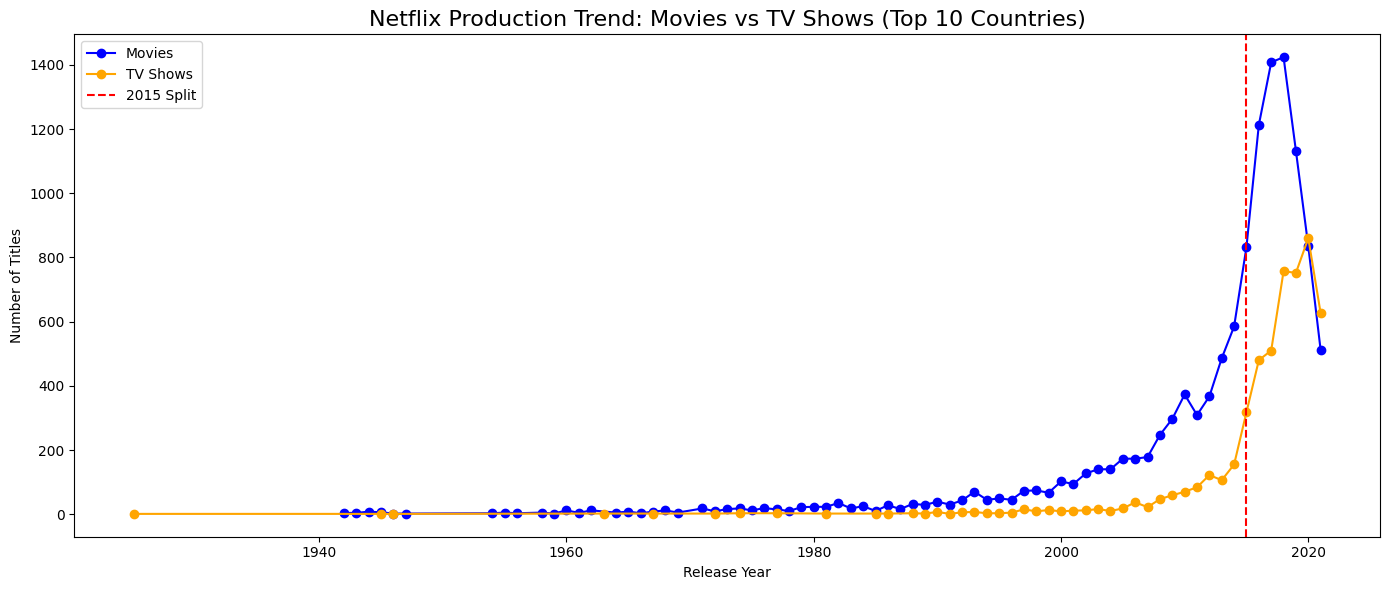

In [0]:

# FILTER ONLY TOP 10 COUNTRIES
df_top10_country = df[df['country'].isin(top10_countries)]


# MOVIE PRODUCTION TREND
df_movie_trend = df_top10_country[df_top10_country['type'] == "Movie"]
df_movie_yearly = df_movie_trend.groupby('release_year').size()


# TV SHOW PRODUCTION TREND
df_tv_trend = df_top10_country[df_top10_country['type'] == "TV Show"]
df_tv_yearly = df_tv_trend.groupby('release_year').size()


# COMBINED LINE PLOT
plt.figure(figsize=(14, 6))

plt.plot(df_movie_yearly.index, df_movie_yearly.values,
         marker='o', label="Movies", color='blue')

plt.plot(df_tv_yearly.index, df_tv_yearly.values,
         marker='o', label="TV Shows", color='orange')

# Split line at 2015
plt.axvline(2015, linestyle='--', color='red', label="2015 Split")

plt.title("Netflix Production Trend: Movies vs TV Shows (Top 10 Countries)", fontsize=16)
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.legend()
plt.tight_layout()
plt.show()
